# Job Posting Classification and Analysis

This project focuses on automatically classifying job postings into different categories using Natural Language Processing (NLP) and Machine Learning techniques.

The system processes job descriptions, converts text into numerical features, and trains a classification model to predict job categories.

## Objectives

• To analyze job posting datasets.

• To preprocess textual job descriptions using NLP techniques.

• To convert text data into numerical features.

• To train a machine learning model for job category classification.

• To analyze job market trends using data visualization.

## 1.IMPORT LIBRARIES

In [55]:
import pandas as pd
import numpy as np
import nltk
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Importing Required Libraries

The following libraries are used in this project:

• pandas – used for loading and processing datasets  
• numpy – used for numerical operations  
• nltk – used for natural language processing tasks  
• matplotlib and seaborn – used for visualization  
• scikit-learn – used for machine learning model training and evaluation

## 2.Download Stopwords

In [56]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\namei\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

What are Stopwords?

Stopwords are common words that do not add important meaning to text, such as:

the,
is,
and,
in,
to,
for,
of.
with

In NLP tasks, these words are usually removed during preprocessing.

## 3.Load Dataset

In [57]:
data = pd.read_csv("D:/coe/machine_learning/job_posting_classification/data/job_dataset.csv")

data.head()

,title,description,category,company
0,Data Scientist,Python machine learning predictive modeling da...,Data Science,Google
1,Machine Learning Engineer,Deep learning neural networks python tensorflo...,Data Science,OpenAI
2,AI Engineer,Artificial intelligence machine learning algor...,Data Science,Nvidia
3,Data Analyst,SQL python data visualization analytics busine...,Data Science,Microsoft
4,Data Engineer,Python spark big data pipelines data processin...,Data Science,Uber


## 4.Dataset Information

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        45 non-null     object
 1   description  45 non-null     object
 2   category     45 non-null     object
 3   company      45 non-null     object
dtypes: object(4)
memory usage: 1.5+ KB


In [59]:
data.shape


(45, 4)

## 5.Check Category Distribution

In [60]:
data["category"].value_counts()

category
Data Science    15
Software        15
Marketing       15
Name: count, dtype: int64

## 6.Visualization

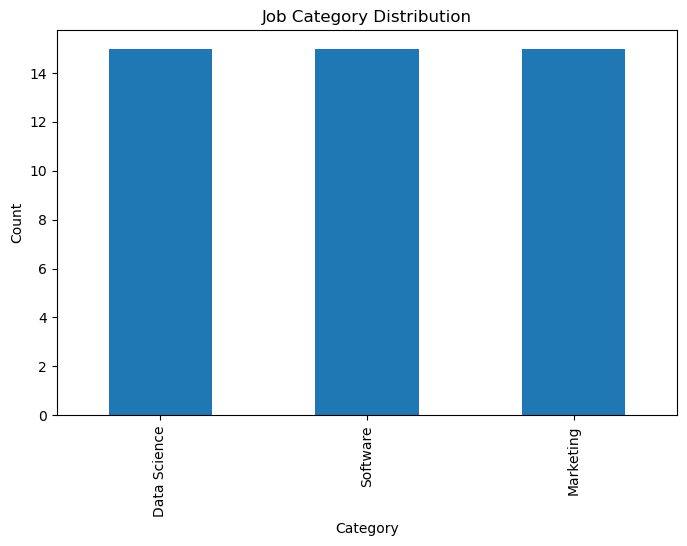

In [61]:
plt.figure(figsize=(8,5))

data["category"].value_counts().plot(kind="bar")

plt.title("Job Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

## Data Visualization

A bar chart is used to visualize the distribution of job categories in the dataset.

This helps us understand which job categories appear more frequently.

## 7.Text Cleaning Function

In [62]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]',' ', text)

    words = text.split()

    stop_words = set(stopwords.words("english"))

    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)

## Text Preprocessing

Text preprocessing is performed to clean job descriptions.

Steps include:

• Convert text to lowercase  
• Remove punctuation and special characters  
• Remove stopwords  
• Keep only meaningful words

## 8.Apply Text Cleaning

In [63]:
data["clean_description"] = data["description"].apply(clean_text)

data.head()

,title,description,category,company,clean_description
0,Data Scientist,Python machine learning predictive modeling da...,Data Science,Google,python machine learning predictive modeling da...
1,Machine Learning Engineer,Deep learning neural networks python tensorflo...,Data Science,OpenAI,deep learning neural networks python tensorflo...
2,AI Engineer,Artificial intelligence machine learning algor...,Data Science,Nvidia,artificial intelligence machine learning algor...
3,Data Analyst,SQL python data visualization analytics busine...,Data Science,Microsoft,sql python data visualization analytics busine...
4,Data Engineer,Python spark big data pipelines data processin...,Data Science,Uber,python spark big data pipelines data processin...


## 9.Convert Text to Features

In [64]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X = vectorizer.fit_transform(data["clean_description"])

y = data["category"]

## Feature Extraction

Machine learning models require numerical input.

TF-IDF (Term Frequency – Inverse Document Frequency) is used to convert textual job descriptions into numerical feature vectors.

## 10.Train Test Split

In [65]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

## Splitting Dataset

The dataset is divided into:

• Training data – used to train the model  
• Testing data – used to evaluate model performance

## 11.Train Model

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X, y)

LogisticRegression(max_iter=2000)

## 12.Predictions

In [67]:
predictions = model.predict(X_test)

predictions

array(['Marketing', 'Software', 'Software', 'Marketing', 'Marketing',
       'Marketing', 'Data Science', 'Data Science', 'Data Science'],
      dtype=object)

## 13.Accuracy

In [68]:
accuracy = accuracy_score(y_test,predictions)

print("Model Accuracy:",accuracy)

Model Accuracy: 1.0


## 14.Model Evaluation

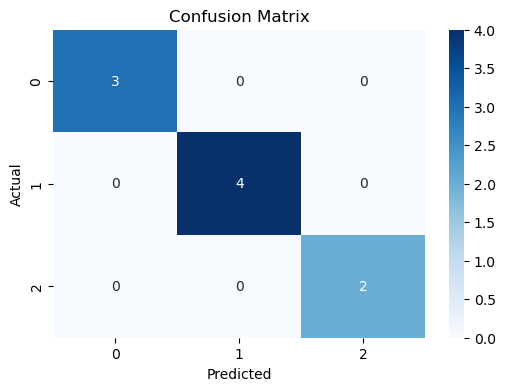

In [69]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 14.Classification Report

In [70]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

Data Science       1.00      1.00      1.00         3
   Marketing       1.00      1.00      1.00         4
    Software       1.00      1.00      1.00         2

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



## Model Evaluation

The model performance is evaluated using:

• Accuracy score  
• Precision  
• Recall  
• F1-score

These metrics help measure how well the model classifies job postings.

## 15.Save Model

In [71]:
import pickle

pickle.dump(model, open("../models/model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))

print("Model saved successfully")

Model saved successfully


## 16. Test Prediction

In [72]:
samples = [
    "Python machine learning deep learning neural networks",
    "Java spring boot backend developer REST API",
    "SEO digital marketing social media campaigns"
]

for text in samples:
    vec = vectorizer.transform([clean_text(text)])
    pred = model.predict(vec)
    print(text, " -> ", pred[0])

Python machine learning deep learning neural networks  ->  Data Science
Java spring boot backend developer REST API  ->  Software
SEO digital marketing social media campaigns  ->  Marketing


## Conclusion

In this project, job postings were analyzed and classified using NLP and machine learning techniques.

Text preprocessing and TF-IDF feature extraction were used to convert job descriptions into numerical form.

A Logistic Regression model was trained to classify job postings into categories.

The model successfully predicts job categories and can be integrated with a user interface for real-time job classification.